<h1><center> Online Shoppers Intention Prediction using Random Forest Classifier</center></h1>

<h1>Introduction</h1>
Online shopping platforms collect customer browsing behavior data to understand whether a visitor is likely to purchase a product.<br>
This project uses supervised machine learning classification algorithms to predict customer purchase intention based on browsing sessions information.
<br>
Two machine learning models are implemented:
<list><ul>
    <li>Logistic Regression</li>
    <li>Random Forest Classifier</li></ul></list>
The performance of both models is evaluated and compared to determine the best model for real-world usage.

## Dataset Resource Reference<br>
<b>Dataset Name:</b> Online shoppers purchasing Intention dataset.<br><br>
<b>Source:</b> https://www.kaggle.com/datasets/henrysue/online-shoppers-intentions

## Objective of the Project
The Objective of this project are:
<list><ul>
    <li>To analyze online shopper behavior data</li>
    <li>To preprocess and prepare the dataset</li>
    <li>To apply machine learning classification algorithms</li>
    <li>To predict whether a customer generates revenue</li>
    <li>To compare Logistic Regression and Random forest models</li>
    <li>To select the best model for real-world applications</li></ul></list>

<h1>Importing Required Libraries</h1>
The following libraries are used for:
<list><ul>
    <li>Data Manipulation</li>
    <li>Visualization</li>
    <li>Preprocessing</li>
    <li>Machine learning model development</li>
    <li>Performance evaluation</li></ul></list>

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder

# Train-test split
from sklearn.model_selection import train_test_split

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
import os 
print(os.listdir())

['.ipynb_checkpoints', 'laptop_prices.csv', 'online_shoppers_intention.csv', 'task_a.ipynb', 'task_b.ipynb']


## Load Dataset
The dataset is loaded into a pandas dataframe for further analysis and preprocessing

In [3]:
# Loading dataset

df = pd.read_csv("online_shoppers_intention.csv")


## Display Dataset
Displaying the dataset helps us understsnd the structure and available columns.

In [4]:
# Display first 5 rows
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Dataset Information
This section provides information about:
<list><ul>
    <li>Number of rows and columns</li>
    <li>Data types</li>
    <li>Non-null values</li></ul></list>

In [5]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

# Data Cleaning 
Data cleaning improves the quality of the dataset before model training.<br>
In this step:
<list><ul>
    <li>Duplicate rows are checked</li>
    <li>Duplicate values are removed</li>
    <li>Unnecessary columns are handled if preseent</li></ul></list>
Clean data helps improve model performance and reliability.

In [6]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())
print("Initial total number of data rows: ",df.shape)

Duplicate Rows: 125
Initial total number of data rows:  (12330, 18)


In [7]:
df=df.drop_duplicates()

In [8]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())
print("After dropping the duplicated data rows: ",df.shape)

Duplicate Rows: 0
After dropping the duplicated data rows:  (12205, 18)


# Dataset Shape
The shape of the dataset is also checked to determine the number of records and features.

In [9]:
print("Dataset Shape: ",df.shape)

Dataset Shape:  (12205, 18)


# Statistical Summary of Dataset
The 'describe()' function is used to display the statistical summary of numerical columns in the dataset.<br>
It provides important information such as:
<list><ul>
    <li>Count</li>
    <li>Mean</li>
    <li>Standard Deviation</li>
    <li>Minimum value</li>
    <li>Maximum value</li>
    <li>Quartile values</li></ul></list>

In [10]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


# Check Missing Values
Missing values can affect model performance and prediction accuracy.<br>
This step checks whether the dataset contains any null or missing values.

In [11]:
# Checking missing values

df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Checking the datatypes of each columns in the dataset

In [12]:
# Checking data types

df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

# Display Columns Names
It is used to display all column name present in the dataset.
<br>
This helps identify:
<list><ul>
    <li>Input features</li>
     <li>Target variable</li>
      <li>Available attributes in the dataset</li></ul></list>

In [13]:
# Display column names

df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')

# Feature Selection
The target variable is Ravenue<br>
All remaining columns are used as input features.

In [14]:
# Selecting dependent and independent variables

X = df.drop("Revenue", axis=1)

y = df["Revenue"]
print("Input Features:")
print(X.columns)

Input Features:
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend'],
      dtype='str')


# Encoding Categorical Variables 
Machine Learning algorithms cannot process categorical text data directly.  Therefore,LableEncoder is used to convert categorical columns into numerical values. 

In [15]:
# Encoding categorical variables using LabelEncoder

le = LabelEncoder()

categorical_columns = X.select_dtypes(include=['object']).columns

for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

# Encoding target column

y = le.fit_transform(y)

In [16]:
print(X.dtypes)

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                        int64
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                  int64
Weekend                       bool
dtype: object


# Exploratory Data Analysis
EDA helps us understand the distribution and relationship between variables.

# Revenue Distribution
Visualizing the distribution of customers who generated revenue and those who did not.

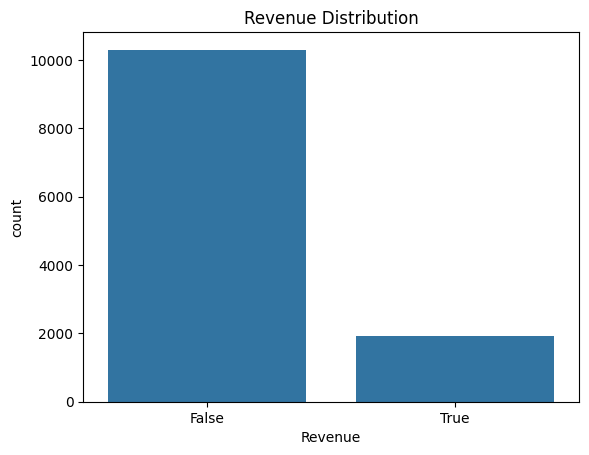

In [17]:
# Revenue distribution

sns.countplot(x=df['Revenue'])

plt.title("Revenue Distribution")
plt.show()

# Visitor Type Distribution
Analyzing different visitor categories.

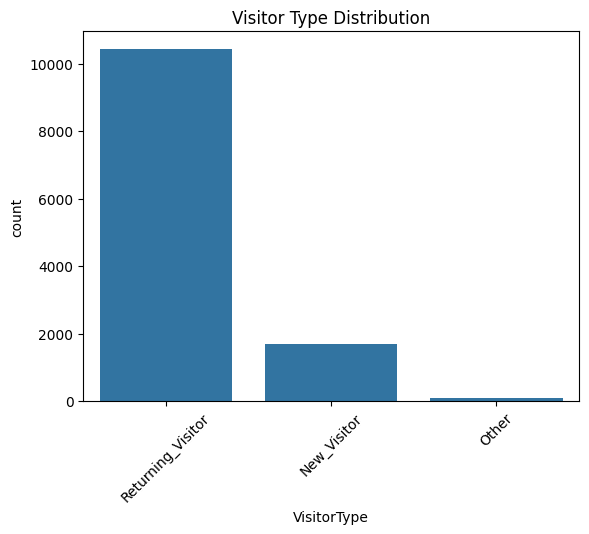

In [18]:
# Visitor type distribution

sns.countplot(x=df['VisitorType'])

plt.title("Visitor Type Distribution")
plt.xticks(rotation=45)
plt.show()

# Monthly visitor Analysis
Analyzing visitor activity across different months.

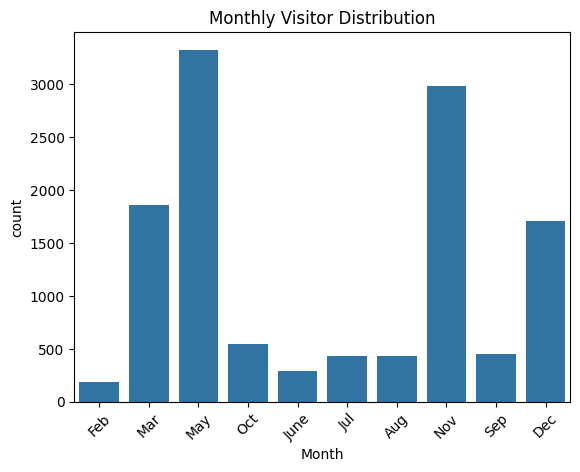

In [19]:
# Month distribution

sns.countplot(x=df['Month'])

plt.title("Monthly Visitor Distribution")
plt.xticks(rotation=45)
plt.show()

# Correlation Heatmap
A Heatmap helps visualize correlations between numerical features.

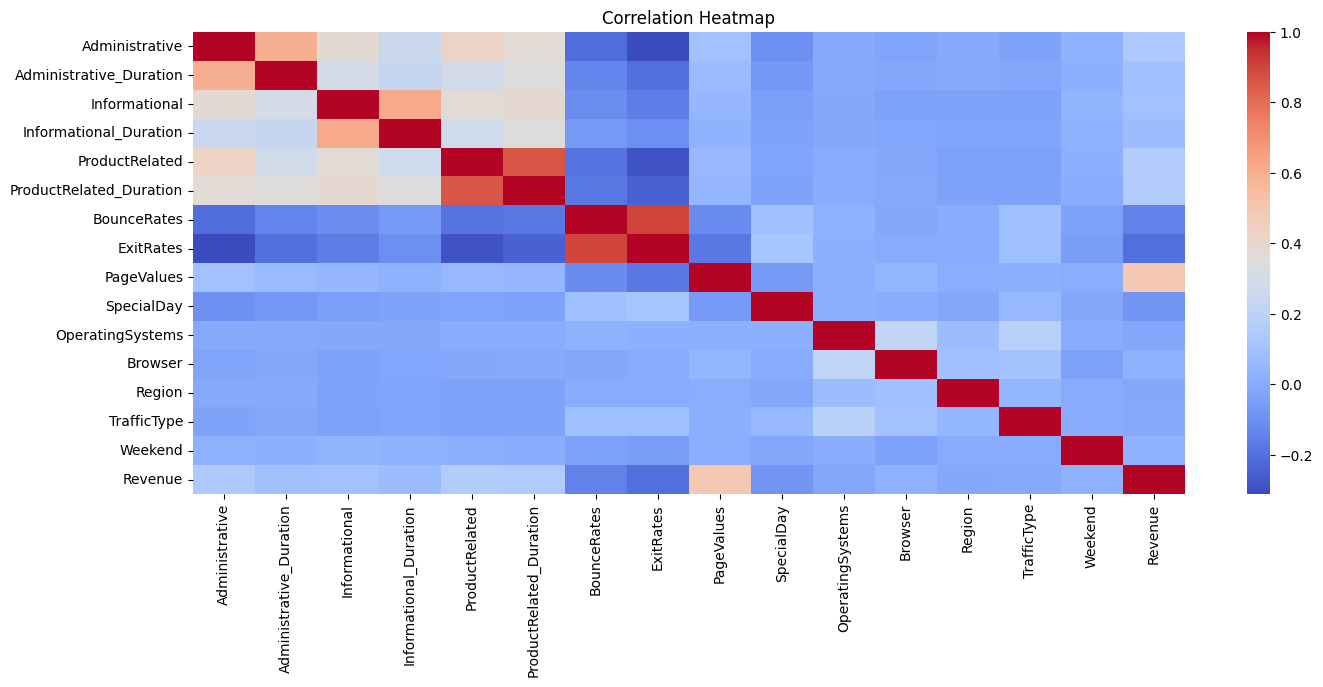

In [21]:
# Correlation heatmap

plt.figure(figsize=(16,6))

sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Train-Test Split 
The dataset is divided into training data and testing data.
<list><ul>
    <li>Training Data: 80%</li>
    <li>Testing Data: 20%</li></ul></list>

In [22]:
# Splitting dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("X Train Shape: ",X_train.shape)
print("X Test Shape: ",X_test.shape)

X Train Shape:  (9764, 17)
X Test Shape:  (2441, 17)


# Model Development using Logistic Regression
Logistic Regression is a supervised classification algorithm used for binary classification problems.

In [23]:
# Creating Logistic Regression model

lr_model = LogisticRegression(max_iter=1000)

# Training model

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Predictionn using Logistic Regression
Predicting output value using the trained Logistic Regression model.

In [24]:
# Predictions using Logistic Regression

y_pred_lr = lr_model.predict(X_test)

# Evaluation of Logistic Regression
Evaluating model performance using:
<list><ul>
    <li>Accuracy</li>
    <li>Precision</li>
    <li>Recall</li>
    <li>F1 Score</li></ul></list>

In [25]:
# Logistic Regression Evaluation
print("Logistic Regression Evaluation")
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression Evaluation
Accuracy : 0.8869315854158132
Precision: 0.7443181818181818
Recall   : 0.36187845303867405
F1 Score : 0.48698884758364314


# Model Development using Random Forest Classifier
Random Forest is an ensemble machine learning algorithm that combines multiple decision trees for better prediction accuracy.

In [26]:
# Creating Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Training model

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Prediction using Random Forest 
Predicting output values using the trained Random forest model.

In [27]:
# Predictions using Random Forest

y_pred_rf = rf_model.predict(X_test)

# Evaluation of Random Forest
Evaluating Random forest performance using multiple classification metrics.

In [28]:
# Random Forest Evaluation

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.9041376485047112
Precision: 0.7406015037593985
Recall   : 0.5441988950276243
F1 Score : 0.6273885350318471


# Confusion Matrix
Confusion Matrix helps visualize:
<list><ul>
    <li>Correct predictions</li>
    <li>Incorrect predictions</li></ul></list>

# Confusion Matrix for Logistic Regression

In [29]:
# Confusion Matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[2034   45]
 [ 231  131]]


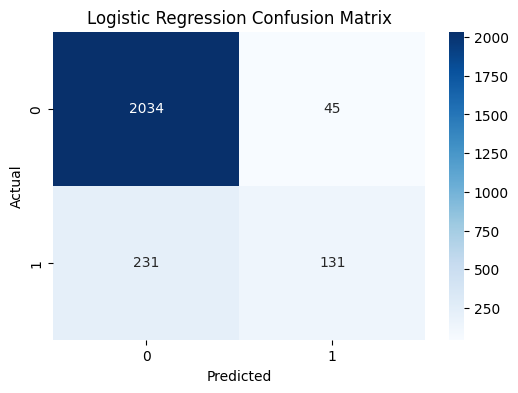

In [30]:
# Logistic Regression confusion matrix visualization

plt.figure(figsize=(6,4))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Confusion Matrix for Random Forest Classifier

In [31]:
# Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[2010   69]
 [ 165  197]]


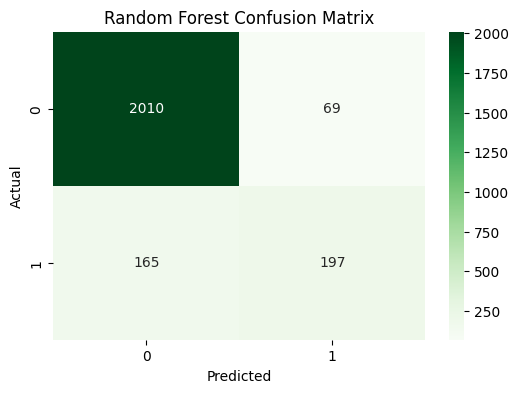

In [32]:
# Random Forest confusion matrix visualization

plt.figure(figsize=(6,4))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Classification Report
Classification report provides detailed performance analysis of classification models.

# Logistic Regression Classification Report 

In [33]:
print("Logistic Regression Classification Report")

print(classification_report(y_test, y_pred_lr))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2079
           1       0.74      0.36      0.49       362

    accuracy                           0.89      2441
   macro avg       0.82      0.67      0.71      2441
weighted avg       0.88      0.89      0.87      2441



# Random Forest Classification Report

In [34]:
print("Random Forest Classification Report")

print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2079
           1       0.74      0.54      0.63       362

    accuracy                           0.90      2441
   macro avg       0.83      0.76      0.79      2441
weighted avg       0.90      0.90      0.90      2441



# Feature Importance Analysis
Feature importance identifies which variables contribute most to prediction.

In [35]:
feature_importance= pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_})
feature_importance=feature_importance.sort_values(by='Importance',ascending=False)
feature_importance

,Feature,Importance
8,PageValues,0.381599
5,ProductRelated_Duration,0.088911
7,ExitRates,0.086749
4,ProductRelated,0.075058
1,Administrative_Duration,0.060763
6,BounceRates,0.056749
10,Month,0.041794
0,Administrative,0.041018
14,TrafficType,0.032249
13,Region,0.029859


# Feature Importance Visualization

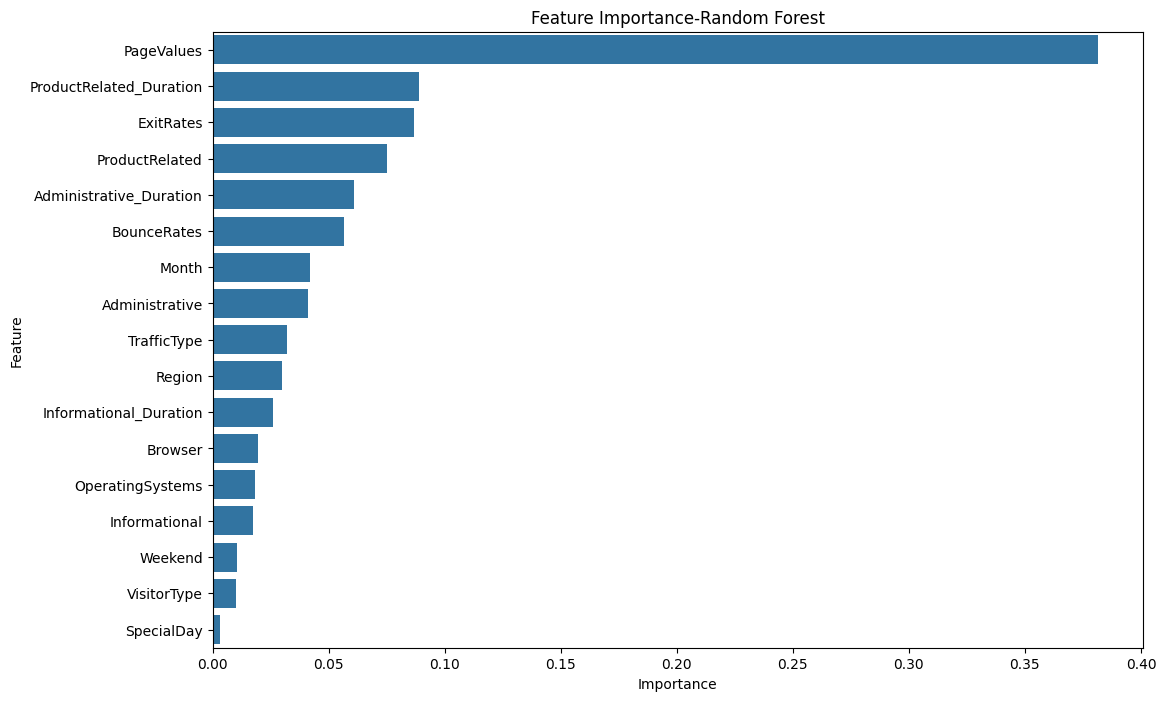

In [36]:
# Feature importance visualization
plt.figure(figsize=(12,8))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)
plt.title("Feature Importance-Random Forest")
plt.show()

# Model Comparison
Comparing Logistic Regression and Random Forest based on:
<list><ul>
    <li>Accuracy</li>
    <li>Precision</li>
    <li>Recall</li>
    <li>F1 score</li></ul></list>

In [87]:
comparison= pd.DataFrame({
    'Model':['Logistic Regression','Random Forest'],
    'Accuracy':[lr_accuracy,rf_accuracy],
    'Precision':[lr_precision,rf_precision],
    'Recall':[lr_recall,rf_recall]
    
})
comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.886932,0.744318,0.361878
1,Random Forest,0.904138,0.740602,0.544199


# Selection of Best Model for Real-world usage
Random Forest is selected as the best model because:
<list><ul>
    <li>Higher accuracy</li>
    <li>Better handling of complex relationships</li>
    <li>Reduced overfitting</li>
    <li>Better overall classification performance</li>
    <li>Supports feature importance analysis</li></ul></list>

In [88]:
print("Selected Best Model: Random Forest Classifier")

Selected Best Model: Random Forest Classifier


# Conclusion
In this project,Machine Learning classification algorithms were used to predict customer purchase intention.<br>
The following models were implemented:
<list><ul>
    <li>Logistic Regression</li>
    <li>Random Forest Classifier</li></ul></list>

After evaluation and comparison,Random Forest achieved better performance in:
<list><ul>
    <li>Accuracy</li>
    <li>Precision</li>
    <li>Recall</li>
    <li>F1 score</li></ul></list>
Therefore, Random forest is considered as the best model for real-world implementation for this dataset.<br>
This project successfully demonstrated:
<list><ul>
    <li>Data preprocessing</li>
    <li>Feature Selection</li>
    <li>Machine learning model development</li>
    <li>Model comparison</li>
    <li>Real-world model selection</li></ul></list>